In [1]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("../data/raw/tickets.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 500
Columns: 12


,ticket_id,employee_name,department,employee_type,subject,description,category,priority,status,created_at,resolved_at,resolution_time_hours
0,1,Employee_37,Sales,Permanent,Internet connection is very slow,Internet connection is very slow,Network,High,Resolved,2026-09-05 06:13:51,2026-09-05 17:06:39,10.88
1,2,Employee_47,Finance,Intern,Software is showing an error,Software is showing an error,Software,Medium,Open,2026-04-25 12:29:51,NaN,27.75
2,3,Employee_48,HR,Intern,Mouse is not responding,Mouse is not responding,Hardware,Low,Resolved,2026-07-03 08:02:51,2026-07-04 06:50:51,22.80
3,4,Employee_41,Finance,Contract,Application is crashing,Application is crashing,Software,Medium,In Progress,2026-05-09 20:05:51,NaN,22.59
4,5,Employee_86,Finance,Intern,Unable to send email,Unable to send email,Email,High,Resolved,2026-08-23 19:18:51,2026-08-23 20:29:03,1.17


In [2]:
# Input and target

X = df["description"]
y = df["category"]

print("Input variable (X):", X.name)
print("Target variable (y):", y.name)

print("\nNumber of samples:", len(X))
print("\nCategories:")
print(y.value_counts())

Input variable (X): description
Target variable (y): category

Number of samples: 500

Categories:
category
Account     93
Network     92
Email       81
Software    79
Security    79
Hardware    76
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=1000
)

# Learn vocabulary from training data and transform it
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF conversion completed!")
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

TF-IDF conversion completed!
Training data shape: (400, 58)
Testing data shape: (100, 58)


In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [6]:
y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
['Network' 'Security' 'Email' 'Security' 'Hardware' 'Hardware' 'Email'
 'Security' 'Account' 'Software']


In [7]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

     Account       1.00      1.00      1.00        19
       Email       1.00      1.00      1.00        16
    Hardware       1.00      1.00      1.00        15
     Network       1.00      1.00      1.00        18
    Security       1.00      1.00      1.00        16
    Software       1.00      1.00      1.00        16

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



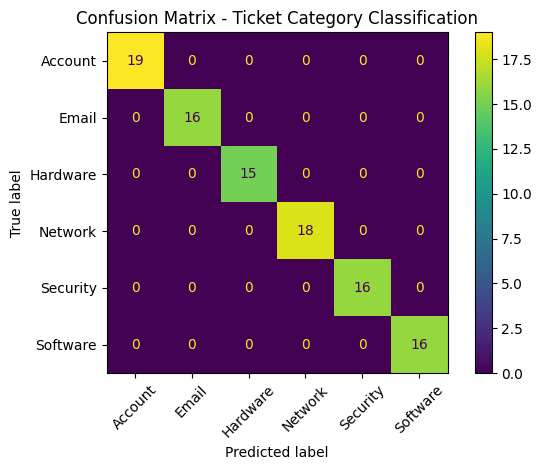

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Ticket Category Classification")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
new_tickets = [
    "My VPN is not connecting",
    "My laptop keyboard is not working",
    "I cannot login to my account",
    "I received a suspicious email"
]

new_tickets_tfidf = vectorizer.transform(new_tickets)

predictions = model.predict(new_tickets_tfidf)

for ticket, prediction in zip(new_tickets, predictions):
    print(f"Ticket: {ticket}")
    print(f"Predicted Category: {prediction}")
    print()

Ticket: My VPN is not connecting
Predicted Category: Network

Ticket: My laptop keyboard is not working
Predicted Category: Hardware

Ticket: I cannot login to my account
Predicted Category: Account

Ticket: I received a suspicious email
Predicted Category: Security

